# Predictive Analysis of E-commerce Orders Using Machine Learning

## Introduction

This project focuses on applying machine learning techniques to an e-commerce dataset to predict order outcomes. The project uses historical order, payment, and customer information to identify patterns that can help in predicting whether an order is successfully delivered.

## Problem Statement

E-commerce platforms generate large amounts of customer and order data. Analyzing this historical data can help identify factors associated with successful or unsuccessful deliveries. This project applies a machine learning classification approach to build a predictive model using relevant features from the e-commerce dataset.

## Objectives

- Prepare and preprocess e-commerce data for machine learning.
- Select relevant features for prediction.
- Build a classification model.
- Train the model using historical data.
- Evaluate the model using appropriate performance metrics.
- Identify useful patterns from the prediction results.

## Technology Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Google Colab

## Expected Outcome

The project will demonstrate how machine learning can be applied to historical e-commerce data to build a predictive model and evaluate its performance using standard classification metrics.

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("All required libraries imported successfully!")

All required libraries imported successfully!


In [ ]:
# Download the Olist datasets

import requests

base_url = "https://raw.githubusercontent.com/olist/work-at-olist-data/master/datasets/"

files = [
    "olist_orders_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_customers_dataset.csv"
]

for file in files:
    response = requests.get(base_url + file)

    if response.status_code == 200:
        with open(file, "wb") as f:
            f.write(response.content)
        print("Downloaded:", file)
    else:
        print("FAILED:", file, "Status:", response.status_code)

print("Download process completed!")

Downloaded: olist_orders_dataset.csv
Downloaded: olist_order_items_dataset.csv
Downloaded: olist_order_payments_dataset.csv
Downloaded: olist_customers_dataset.csv
Download process completed!


In [ ]:
# Load the datasets using Pandas

orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [ ]:
# Check the size of each dataset

print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Customers:", customers.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Customers: (99441, 5)


In [ ]:
# Create the target variable

orders["delivered"] = (
    orders["order_status"] == "delivered"
).astype(int)

print(orders[["order_status", "delivered"]].head(10))

  order_status  delivered
0    delivered          1
1    delivered          1
2    delivered          1
3    delivered          1
4    delivered          1
5    delivered          1
6     invoiced          0
7    delivered          1
8    delivered          1
9    delivered          1


In [ ]:
# Prepare the dataset for machine learning

# Select useful payment information for each order
payment_features = payments.groupby("order_id").agg(
    payment_value=("payment_value", "sum"),
    payment_installments=("payment_installments", "max")
).reset_index()

# Select customer information
customer_features = customers[
    ["customer_id", "customer_state"]
]

# Merge orders with payment information
ml_data = orders.merge(
    payment_features,
    on="order_id",
    how="left"
)

# Merge customer information
ml_data = ml_data.merge(
    customer_features,
    on="customer_id",
    how="left"
)

print("Machine learning dataset created!")
print("Shape:", ml_data.shape)

Machine learning dataset created!
Shape: (99441, 12)


In [ ]:
# Select features for the machine learning model

features = [
    "payment_value",
    "payment_installments",
    "customer_state"
]

target = "delivered"

ml_data = ml_data[features + [target]].copy()

print("Selected features:")
print(features)

print("\nTarget variable:")
print(target)

print("\nFinal dataset shape:", ml_data.shape)

Selected features:
['payment_value', 'payment_installments', 'customer_state']

Target variable:
delivered

Final dataset shape: (99441, 4)


In [ ]:
# Check for missing values

print("Missing values in each column:")
print(ml_data.isnull().sum())

Missing values in each column:
payment_value           1
payment_installments    1
customer_state          0
delivered               0
dtype: int64


In [ ]:
# Handle missing values in numerical features

ml_data["payment_value"] = ml_data["payment_value"].fillna(
    ml_data["payment_value"].median()
)

ml_data["payment_installments"] = ml_data["payment_installments"].fillna(
    ml_data["payment_installments"].median()
)

print("Missing values handled successfully!")
print(ml_data.isnull().sum())

Missing values handled successfully!
payment_value           0
payment_installments    0
customer_state          0
delivered               0
dtype: int64


In [ ]:
# Separate features and target

X = ml_data[[
    "payment_value",
    "payment_installments",
    "customer_state"
]]

y = ml_data["delivered"]

# Identify numerical and categorical columns
numerical_features = [
    "payment_value",
    "payment_installments"
]

categorical_features = [
    "customer_state"
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Target:", target)

Numerical features: ['payment_value', 'payment_installments']
Categorical features: ['customer_state']
Target: delivered


In [ ]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 79552
Testing records: 19889


In [ ]:
# Build the preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
# Create and train the Logistic Regression model

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
# Make predictions on the test dataset

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred[:10])

Predictions generated successfully!
First 10 predictions: [1 1 1 1 1 1 1 1 1 1]


In [ ]:
# Evaluate the Logistic Regression model

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Model Performance
------------------
Accuracy : 0.9702
Precision: 0.9702
Recall   : 1.0
F1-Score : 0.9849


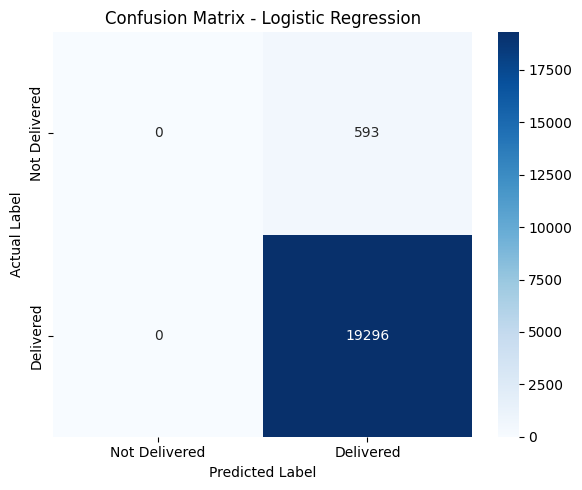

In [ ]:
# Create the confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Delivered", "Delivered"],
    yticklabels=["Not Delivered", "Delivered"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [ ]:
# Detailed classification report

print("Classification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Delivered", "Delivered"],
        zero_division=0
    )
)

Classification Report
---------------------
               precision    recall  f1-score   support

Not Delivered       0.00      0.00      0.00       593
    Delivered       0.97      1.00      0.98     19296

     accuracy                           0.97     19889
    macro avg       0.49      0.50      0.49     19889
 weighted avg       0.94      0.97      0.96     19889



In [ ]:
# Train an improved Logistic Regression model with class balancing

balanced_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

balanced_model.fit(X_train, y_train)

# Make predictions
y_pred_balanced = balanced_model.predict(X_test)

print("Balanced Logistic Regression model trained successfully!")

Balanced Logistic Regression model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Evaluate the balanced Logistic Regression model

accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced, zero_division=0)
recall_balanced = recall_score(y_test, y_pred_balanced, zero_division=0)
f1_balanced = f1_score(y_test, y_pred_balanced, zero_division=0)

print("Balanced Model Performance")
print("--------------------------")
print("Accuracy :", round(accuracy_balanced, 4))
print("Precision:", round(precision_balanced, 4))
print("Recall   :", round(recall_balanced, 4))
print("F1-Score :", round(f1_balanced, 4))

Balanced Model Performance
--------------------------
Accuracy : 0.578
Precision: 0.9763
Recall   : 0.579
F1-Score : 0.7269


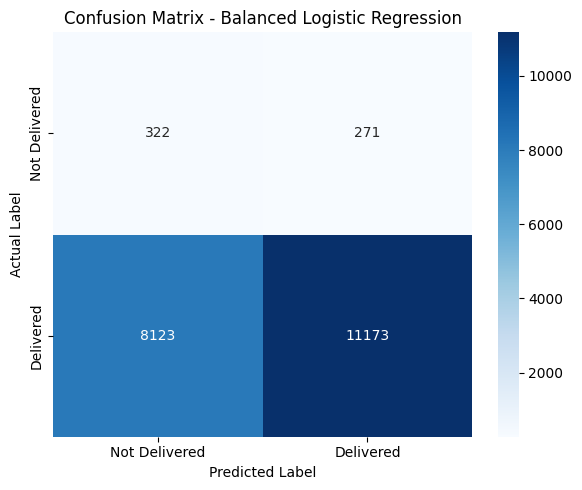

In [ ]:
# Confusion matrix for the balanced model

cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Delivered", "Delivered"],
    yticklabels=["Not Delivered", "Delivered"]
)

plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

## Model Comparison

Two Logistic Regression models were evaluated during the analysis.

| Metric | Original Logistic Regression | Balanced Logistic Regression |
|---|---:|---:|
| Accuracy | 97.02% | 57.80% |
| Precision | 97.02% | 97.63% |
| Recall | 100.00% | 57.90% |
| F1-Score | 98.49% | 72.69% |

The original model achieved higher overall accuracy, but its confusion matrix showed that it classified all test cases as delivered and therefore failed to identify the minority Not Delivered class.

The balanced model was trained using class balancing. It was able to identify some Not Delivered orders, although this resulted in lower overall accuracy and more incorrect predictions for delivered orders.

This comparison demonstrates the importance of evaluating classification models using multiple metrics rather than relying only on accuracy.

## Key Insights

1. The dataset contained 99,441 orders, providing a substantial historical dataset for predictive analysis.

2. Payment value, payment installments, and customer state were selected as the main predictive features.

3. The original Logistic Regression model achieved an accuracy of 97.02% and an F1-score of 98.49%.

4. The original model showed a strong class-imbalance problem because it did not correctly identify any Not Delivered orders.

5. Class balancing allowed the second model to identify some Not Delivered orders, demonstrating the effect of addressing class imbalance.

6. The balanced model achieved 57.80% accuracy and a 72.69% F1-score for the Delivered class.

7. The results show that model evaluation should consider accuracy, precision, recall, F1-score, and the confusion matrix together.

## Conclusion

This project demonstrated the application of machine learning to historical e-commerce order data. The data was prepared through feature selection, missing-value handling, categorical encoding, and an 80:20 train-test split.

Logistic Regression was used to build a classification model for predicting whether an order was delivered. Two versions of the model were evaluated: an original model and a class-balanced model.

The analysis showed that class imbalance can significantly affect classification results. Therefore, evaluating a predictive model using multiple performance metrics provides a more complete understanding of its behaviour than accuracy alone.

Overall, the project demonstrates how machine learning can be applied to e-commerce data to identify patterns and support predictive analysis.